# Temporary Project Notebook - LoL

**Name(s)**: Amy Trinh, Nghi Nguyen

**Website Link**: (your website link)

In [18]:
import pandas as pd
import numpy as np
from pathlib import Path

import plotly.express as px
pd.options.plotting.backend = 'plotly'

import matplotlib.pyplot as plt
import seaborn as sns


## Step 1: Introduction

In [2]:
# Step: Introduction and Question Identification

# Analysis in Notebook:
# Understand the data you have access to. 
# Brainstorm a few questions that interest you about the dataset.
# Pick one question you plan to investigate further. 
# (As the data science lifecycle tells us, this question may change as you work on your project.)

# Report on Website:
# Provide an introduction to your dataset, and clearly state the one question your project is centered around. 
# Why should readers of your website care about the dataset and your question specifically? 
# Report the number of rows in the dataset, the names of the columns that are relevant to your question, and descriptions of those relevant columns.

<u>**Dataset:**</u>

2025 League of Legends Dataset from OracleElixer
https://drive.google.com/drive/u/0/folders/1gLSw0RLjBbtaNy0dgnGQDAZOHIgCe-HH 

<u>**Why did you choose this dataset?**</u>

We chose this dataset because we have a strong interest in League of Legends. The game has a lot of different factors that can impact the flow and result of each match, making it suitable to try to predict certain aspects of the game such as the win rate. In addition, the dataset is extremely comprehensive, as it has a lot of samples and has lots of different features (165 columns) that can be analyzed and tested on. This gives us a lot of options as to what we should test.

<u>**Research Question**</u>

Which stat is a better predictor of winning: a team's kills or the total monster objectives they take (dragons + barons + void_grubs)?

<u>**Introduction to Dataset**</u>

<u>**Explanation of Dataset (Rows and Columns)**</u>

<u>**Hypothesis Testing (will move to those steps later on)**</u>

We can do 2 different hypothesis tests using difference in means (t-test). This will allow us to make a prediciion as to which stat would be better for predicting if a team wins.

For number of kills:

Null Hypothesis: The mean number of total kills secured by winning teams is equal to or less than the mean number of kills secured by losing teams.

Alternative Hypothesis: The mean number of total kills secured by winning teams is greater than the mean number of kills secured by losing teams.

For number of monster objectives:

Null Hypothesis: The mean number of monster objectives secured by winning teams is equal to or less than the mean number of objectives secured by losing teams.

Alternative Hypothesis: The mean number of objectives secured by winning teams is greater than the mean number of objectives secured by losing teams.

<u>**Predictive Modeling**</u>

Column We're Predicting: "result" (whether the team wins or loses)

Type of Model: Classification, where 1.0 is win and 0.0 is lose

## Step 2: Data Cleaning and Exploratory Data Analysis

In [3]:
# Data Cleaning 
# Analysis in Notebook: 
# Clean the data appropriately. 
# For instance, you may need to replace data that should be missing with NaN or create new columns out of given ones 
# (e.g. compute distances, scale data, or get time information from time stamps)

# Report on Website:
# Describe, in detail, the data cleaning steps you took and how they affected your analyses.
# The steps should be explained in reference to the data generating process. 
# Show the head of your cleaned DataFrame (see Part 2: Report for instructions).

In [4]:
df = pd.read_csv("2025_LoL_esports_match_data_from_OraclesElixir.csv", low_memory=False)

In [5]:
pd.set_option('display.max_columns', None)
df.head(12) #12 rows for each game, 5 for each of the two teams then 2 for the combined team data

# if position = 'team', then row provides combined data for every player on the team.
# "result" - 1 means win, 0 means loss.

,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,participantid,side,position,playername,playerid,teamname,teamid,firstPick,champion,ban1,ban2,ban3,ban4,ban5,pick1,pick2,pick3,pick4,pick5,gamelength,result,kills,deaths,assists,teamkills,teamdeaths,doublekills,triplekills,quadrakills,pentakills,firstblood,firstbloodkill,firstbloodassist,firstbloodvictim,team kpm,ckpm,firstdragon,dragons,opp_dragons,elementaldrakes,opp_elementaldrakes,infernals,mountains,clouds,oceans,chemtechs,hextechs,dragons (type unknown),elders,opp_elders,firstherald,heralds,opp_heralds,void_grubs,opp_void_grubs,firstbaron,barons,opp_barons,atakhans,opp_atakhans,firsttower,towers,opp_towers,firstmidtower,firsttothreetowers,turretplates,opp_turretplates,inhibitors,opp_inhibitors,damagetochampions,dpm,damageshare,damagetakenperminute,damagemitigatedperminute,damagetotowers,wardsplaced,wpm,wardskilled,wcpm,controlwardsbought,visionscore,vspm,totalgold,earnedgold,earned gpm,earnedgoldshare,goldspent,gspd,gpr,total cs,minionkills,monsterkills,monsterkillsownjungle,monsterkillsenemyjungle,cspm,goldat10,xpat10,csat10,opp_goldat10,opp_xpat10,opp_csat10,golddiffat10,xpdiffat10,csdiffat10,killsat10,assistsat10,deathsat10,opp_killsat10,opp_assistsat10,opp_deathsat10,goldat15,xpat15,csat15,opp_goldat15,opp_xpat15,opp_csat15,golddiffat15,xpdiffat15,csdiffat15,killsat15,assistsat15,deathsat15,opp_killsat15,opp_assistsat15,opp_deathsat15,goldat20,xpat20,csat20,opp_goldat20,opp_xpat20,opp_csat20,golddiffat20,xpdiffat20,csdiffat20,killsat20,assistsat20,deathsat20,opp_killsat20,opp_assistsat20,opp_deathsat20,goldat25,xpat25,csat25,opp_goldat25,opp_xpat25,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
0,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,1,Blue,top,PatkicaA,oe:player:c659697694306de62d978569b84c344,IziDream,oe:team:84bc703e28859788770611d94cf02ac,1.0,Gnar,Vi,Skarner,Corki,K'Sante,Sylas,NaN,NaN,NaN,NaN,NaN,1592,0,1,2,1,3,13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.1131,0.603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,20156,759.6482,0.401970,681.2186,629.7362,7451.0,9,0.3392,2,0.0754,3,17,0.6407,10668,7145,269.2839,0.289981,9793,NaN,NaN,234.0,234.0,0,NaN,NaN,8.8191,3058.0,4466.0,75.0,3394.0,4603.0,79.0,-336.0,-137.0,-4.0,0.0,0.0,1.0,1.0,0.0,0.0,4531.0,6777.0,119.0,5372.0,6968.0,125.0,-841.0,-191.0,-6.0,0.0,0.0,1.0,1.0,2.0,0.0,6473.0,9072.0,154.0,7012.0,9562.0,154.0,-539.0,-490.0,0.0,1.0,1.0,2.0,2.0,2.0,2.0,9244.0,12552.0,217.0,9020.0,12553.0,200.0,224.0,-1.0,17.0,1.0,1.0,2.0,2.0,4.0,2.0
1,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,2,Blue,jng,Joinze,oe:player:dbdc61a1c41acedcbc7d399727155ac,IziDream,oe:team:84bc703e28859788770611d94cf02ac,1.0,Maokai,Vi,Skarner,Corki,K'Sante,Sylas,NaN,NaN,NaN,NaN,NaN,1592,0,0,3,1,3,13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1131,0.603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,4963,187.0477,0.098977,906.9724,954.6106,0.0,7,0.2638,7,0.2638,6,29,1.0930,7429,3906,147.2111,0.158520,7200,NaN,NaN,143.0,11.0,132,NaN,NaN,5.3894,2977.0,3153.0,62.0,3451.0,3687.0,71.0,-474.0,-534.0,-9.0,0.0,0.0,0.0,0.0,1.0,0.0,4461.0,5316.0,97.0,5289.0,5332.0,91.0,-828.0,-16.0,6.0,0.0,0.0,0.0,0.0,3.0,0.0,5668.0,6978.0,118.0,7357.0,8317.0,133.0,-1689.0,-1339.0,-15.0,0.0,1.0,1.0,0.0,5.0,0.0,7040.0,8877.0,139.0,9403.0,10321.0,157.0,-2363.0,-1444.0,-18.0,0.0,1.0,2.0,1.0,7.0,0.0
2,LOLTMNT03_179647,complete,NaN,LFL2,2025,Winter,0,2025-01-11 11:11:24,1,15.01,3,Blue,mid,Sayn,oe:player:694d028e62f4ea668b206ab752b6f94,IziDream,oe:team:84bc703e28859788770611d94cf02ac,1.0,Hwei,Vi,Skarner,Corki,K'Sante,Sylas,NaN,NaN,NaN,NaN,NaN,1592,0,1,2,0,3,13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1131,0.603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [6]:
#print(df.columns.tolist())
# filter out columns that we don't need and only keep the columns that are somewhat relevant to our hypothesis testing and prediction task
key_col = ['gameid','participantid','side','position','result',
          'kills', 'deaths', 'assists', 'doublekills', 'triplekills', 'quadrakills', 'pentakills', 'firstblood',
         'dragons','infernals','mountains','clouds','oceans','chemtechs','hextechs','elders','heralds', 'void_grubs','barons']

df = df.drop(columns=[col for col in df.columns if col not in key_col])
df

,gameid,participantid,side,position,result,kills,deaths,assists,doublekills,triplekills,quadrakills,pentakills,firstblood,dragons,infernals,mountains,clouds,oceans,chemtechs,hextechs,elders,heralds,void_grubs,barons
0,LOLTMNT03_179647,1,Blue,top,0,1,2,1,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,LOLTMNT03_179647,2,Blue,jng,0,0,3,1,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,LOLTMNT03_179647,3,Blue,mid,0,1,2,0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,LOLTMNT03_179647,4,Blue,bot,0,1,3,1,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,LOLTMNT03_179647,5,Blue,sup,0,0,3,2,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120451,LOLTMNT03_332179,8,Red,mid,1,14,2,7,4.0,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
120452,LOLTMNT03_332179,9,Red,bot,1,0,3,12,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
120453,LOLTMNT03_332179,10,Red,sup,1,1,1,18,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
120454,LOLTMNT03_332179,100,Blue,team,0,9,22,20,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0


In [7]:
# we only want to look at the team data, so we will drop the player data (position != 'team' or participantid != 100 or 200)

df = df[((df['participantid'] == 100) | (df['participantid'] == 200)) & (df['position'] == 'team')]
df.reset_index(inplace=True, drop=True)
df

,gameid,participantid,side,position,result,kills,deaths,assists,doublekills,triplekills,quadrakills,pentakills,firstblood,dragons,infernals,mountains,clouds,oceans,chemtechs,hextechs,elders,heralds,void_grubs,barons
0,LOLTMNT03_179647,100,Blue,team,0,3,13,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,LOLTMNT03_179647,200,Red,team,1,13,3,36,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0
2,LOLTMNT06_96134,100,Blue,team,1,21,11,53,3.0,0.0,0.0,0.0,1.0,3.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0
3,LOLTMNT06_96134,200,Red,team,0,10,21,22,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,LOLTMNT06_95160,100,Blue,team,0,18,22,30,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20071,LOLTMNT03_332178,200,Red,team,1,15,3,37,2.0,0.0,0.0,0.0,1.0,3.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,3.0,1.0
20072,LOLTMNT03_331511,100,Blue,team,0,11,24,29,0.0,0.0,0.0,0.0,0.0,4.0,0.0,1.0,0.0,0.0,2.0,1.0,0.0,1.0,1.0,0.0
20073,LOLTMNT03_331511,200,Red,team,1,24,11,56,4.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0,2.0
20074,LOLTMNT03_332179,100,Blue,team,0,9,22,20,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0


In [8]:
df.isnull().sum().sort_values(ascending=False)
#will be analyzed later on in assessment of missingness

infernals        1634
elders           1634
hextechs         1634
chemtechs        1634
oceans           1634
doublekills      1634
triplekills      1634
quadrakills      1634
pentakills       1634
clouds           1634
mountains        1634
gameid              0
void_grubs          0
heralds             0
firstblood          0
dragons             0
participantid       0
assists             0
deaths              0
kills               0
result              0
position            0
side                0
barons              0
dtype: int64

In [ ]:
df['total_monster_objectives'] = df['dragons'] + df['heralds'] + df['barons'] + df['void_grubs']
# infernals, mountains, clouds, oceans, chemtechs, hextechs, and elders are types of dragons and are already included in total
# note that the original dataset has a column called monsterkills, but that includes regular jungle monsters
# we are only interested in the major monster objectives that teams secure together (since they give buffs)

df = df.rename(columns={'kills': 'total_kills'})
#kills are already summed for the whole team, so we don't need to sum them up again
#doublekills, triplekills, quadrakills, pentakills are for the type of kills, and already included in total

df.head()


/var/folders/jn/2yd4xw3j43l6tt2w0gfb6nh80000gn/T/ipykernel_51690/4100942757.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['total_monster_objectives'] = df['dragons'] + df['heralds'] + df['barons'] + df['void_grubs']


,gameid,participantid,side,position,result,total_kills,deaths,assists,doublekills,triplekills,quadrakills,pentakills,firstblood,dragons,infernals,mountains,clouds,oceans,chemtechs,hextechs,elders,heralds,void_grubs,barons,total_monster_objectives
0,LOLTMNT03_179647,100,Blue,team,0,3,13,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,LOLTMNT03_179647,200,Red,team,1,13,3,36,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0,10.0
2,LOLTMNT06_96134,100,Blue,team,1,21,11,53,3.0,0.0,0.0,0.0,1.0,3.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,1.0,11.0
3,LOLTMNT06_96134,200,Red,team,0,10,21,22,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0
4,LOLTMNT06_95160,100,Blue,team,0,18,22,30,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0


In [10]:
# Univariate Analysis	

# Analysis in Notebook:
# Look at the distributions of relevant columns separately by using DataFrame operations and drawing at least two relevant plots.

# Report on Website:
# Embed at least one plotly plot you created in your notebook that displays the distribution of a single column
#  Include a 1-2 sentence explanation about your plot, making sure to describe and interpret any trends present.
# (Your notebook will likely have more visualizations than your website, and that’s fine. 
# Feel free to embed more than one univariate visualization in your website if you’d like, 
# but make sure that each embedded plot is accompanied by a description.)

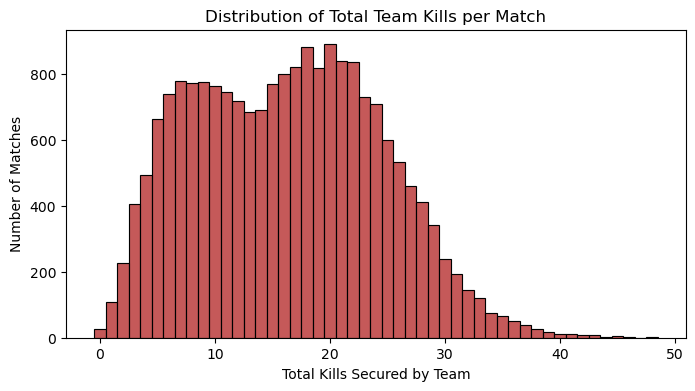

In [45]:
# total kills distribution
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='total_kills',  color='firebrick', discrete=True)
plt.title('Distribution of Total Team Kills per Match')
plt.xlabel('Total Kills Secured by Team')
plt.ylabel('Number of Matches')
plt.show()

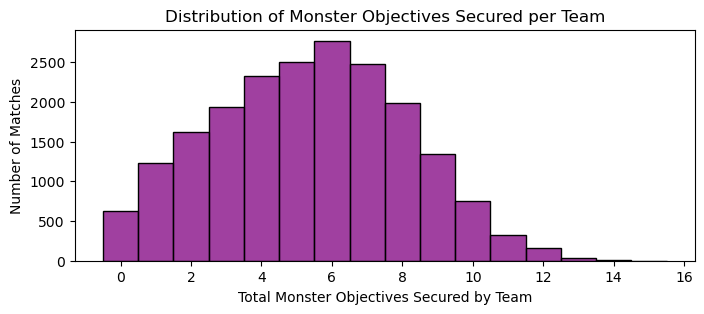

In [ ]:
# monster objectives distribution
plt.figure(figsize=(8, 3))
sns.histplot(data=df, x='total_monster_objectives', color='purple', discrete=True)
plt.xlabel('Total Monster Objectives Secured by Team')
plt.ylabel('Number of Matches')
plt.title('Distribution of Monster Objectives Secured per Team')
plt.show()

/var/folders/jn/2yd4xw3j43l6tt2w0gfb6nh80000gn/T/ipykernel_51690/1662715490.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=multikill_totals.index, y=multikill_totals.values, palette='magma')


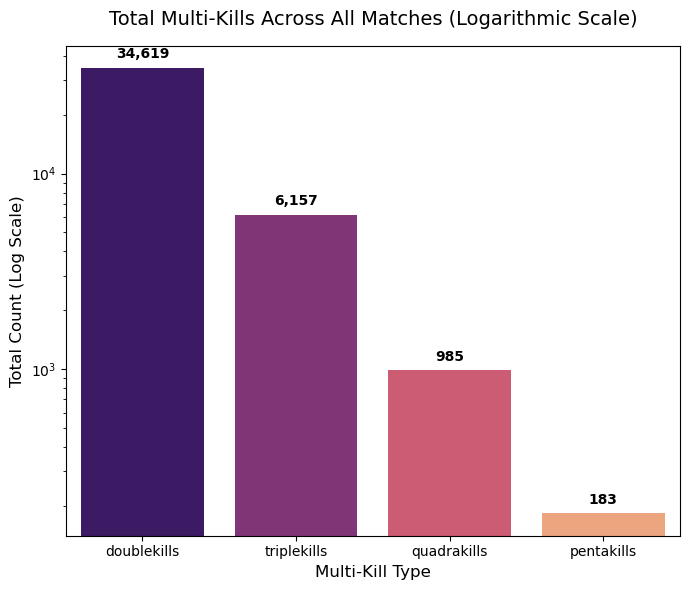

In [ ]:
# multi kill distribution
multikill_totals = df[['doublekills', 'triplekills', 'quadrakills', 'pentakills']].sum()

plt.figure(figsize=(7, 6))
sns.barplot(x=multikill_totals.index, y=multikill_totals.values, palette='magma')

plt.yscale('log')

plt.title('Total Multi-Kills Across All Matches (Logarithmic Scale)', fontsize=14, pad=15)
plt.xlabel('Multi-Kill Type', fontsize=12)
plt.ylabel('Total Count (Log Scale)', fontsize=12)

ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, 
                    weight='bold')

plt.tight_layout()
plt.show()

/var/folders/jn/2yd4xw3j43l6tt2w0gfb6nh80000gn/T/ipykernel_51690/4294148938.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dragon_totals.index, y=dragon_totals.values, ax=ax, palette='vlag')


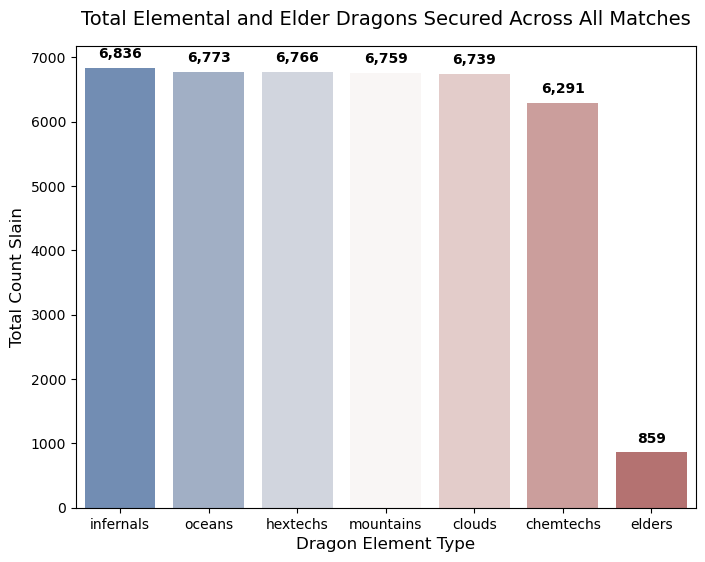

In [78]:
dragon_columns = ['infernals', 'mountains', 'clouds', 'oceans', 'chemtechs', 'hextechs', 'elders']

dragon_totals = df[dragon_columns].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=dragon_totals.index, y=dragon_totals.values, ax=ax, palette='vlag')

ax.set_title('Total Elemental and Elder Dragons Secured Across All Matches', fontsize=14, pad=15)
ax.set_xlabel('Dragon Element Type', fontsize=12)
ax.set_ylabel('Total Count Slain', fontsize=12)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, 
                    weight='bold')

/var/folders/jn/2yd4xw3j43l6tt2w0gfb6nh80000gn/T/ipykernel_51690/393453195.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=objective_totals.index, y=objective_totals.values, ax=ax, palette='viridis')


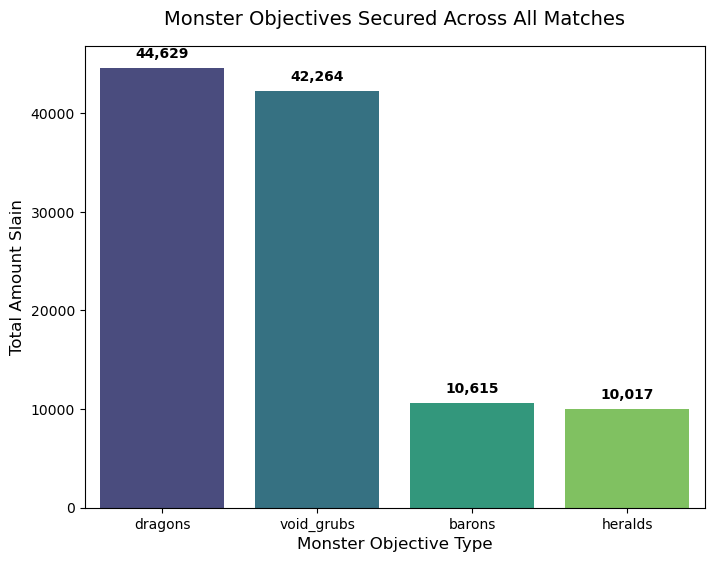

In [79]:
objective_columns = ['dragons', 'heralds', 'barons', 'void_grubs']

objective_totals = df[objective_columns].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=objective_totals.index, y=objective_totals.values, ax=ax, palette='viridis')

ax.set_title('Monster Objectives Secured Across All Matches', fontsize=14, pad=15)
ax.set_xlabel('Monster Objective Type', fontsize=12)
ax.set_ylabel('Total Amount Slain', fontsize=12)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, 
                    weight='bold')



In [ ]:
# Bivariate Analysis	

# Analysis in Notebook:
# Look at the statistics of pairs of columns to identify possible associations.
# For instance, you may create scatter plots and plot conditional distributions, or box-plots. 
# You must plot at least two such plots in your notebook. 
# The results of your bivariate analyses will be helpful in identifying interesting hypothesis tests!

# Report on Website:
# Embed at least one plotly plot that displays the relationship between two columns. 
# Include a 1-2 sentence explanation about your plot, making sure to describe and interpret any trends present. 
# (Your notebook will likely have more visualizations than your website, and that’s fine. 
# Feel free to embed more than one bivariate visualization in your website if you’d like, but make sure that each embedded plot is accompanied by a description.

In [ ]:
#Interesting Aggregates	

# Analysis in Notebook:
# Choose columns to group and pivot by and examine aggregate statistics.

# Report on Website:
# Embed at least one grouped table or pivot table in your website and explain its significance.

## Step 3: Assessment of Missingness

In [11]:
# TODO

## Step 4: Hypothesis Testing

## Step 5: Framing a Prediction Problem

In [12]:
# TODO

## Step 6: Baseline Model

In [13]:
# TODO

## Step 7: Final Model

In [14]:
# TODO

## Step 8: Fairness Analysis

In [15]:
# TODO